# **1. Import Libraries**

In [2]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# **2. Dataset Path**

In [3]:
DATASET_PATH = r"C:\Users\Tushti Gupta\Desktop\Tushti Gupta\vehicle_data"

# **3. Load Images using OpenCV**

In [4]:
IMG_SIZE = 128

categories = os.listdir(DATASET_PATH)
print("Classes:", categories)

data = []
labels = []

for label, category in enumerate(categories):
    folder_path = os.path.join(DATASET_PATH, category)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        try:
            # Read image
            img = cv2.imread(img_path)

            # Resize
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # Convert BGR → RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Normalize
            img = img / 255.0

            data.append(img)
            labels.append(label)

        except:
            pass

X = np.array(data)
y = np.array(labels)

Classes: ['airplane', 'ambulance', 'bicycle', 'boat', 'bus', 'car', 'fire_truck', 'helicopter', 'hovercraft', 'jet_ski', 'kayak', 'motorcycle', 'rickshaw', 'scooter', 'segway', 'skateboard', 'tractor', 'truck', 'unicycle', 'van']


# **4. Train / Validation / Test Split**

In [5]:
# First split (train + temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Second split (validation + test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# **5. One-Hot Encoding**

In [6]:
num_classes = len(categories)

y_train = to_categorical(y_train, num_classes)
y_val = to_categorical(y_val, num_classes)
y_test = to_categorical(y_test, num_classes)

# **6. CNN Model**

In [7]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\Tushti Gupta\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 20)                  │           5,140 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,521,172 (24.88 MB)

 Trainable params: 6,521,172 (24.88 MB)

 Non-trainable params: 0 (0.00 B)

# **7. Train Model**

In [8]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 27s 261ms/step - accuracy: 0.0889 - loss: 2.9640 - val_accuracy: 0.0937 - val_loss: 2.8417
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 40s 246ms/step - accuracy: 0.1596 - loss: 2.7337 - val_accuracy: 0.2234 - val_loss: 2.5579
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 247ms/step - accuracy: 0.2505 - loss: 2.4584 - val_accuracy: 0.3045 - val_loss: 2.3080
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 248ms/step - accuracy: 0.3444 - loss: 2.1443 - val_accuracy: 0.3045 - val_loss: 2.2632
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 248ms/step - accuracy: 0.4117 - loss: 1.8646 - val_accuracy: 0.3856 - val_loss: 2.0752
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 249ms/step - accuracy: 0.5095 - loss: 1.5338 - val_accuracy: 0.3910 - val_loss: 2.0232
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 247ms/step - accuracy: 0.6216 - loss: 1.2031 - val_accuracy: 0.4036 - val_loss: 2.1389
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 246ms/step - accuracy: 0.6935 - loss: 0.9913 - val_accu

# **8. Evaluate Model**

In [9]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.4270 - loss: 2.2037 
Test Accuracy: 0.42702701687812805
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step 


# **9. Confusion Matrix**

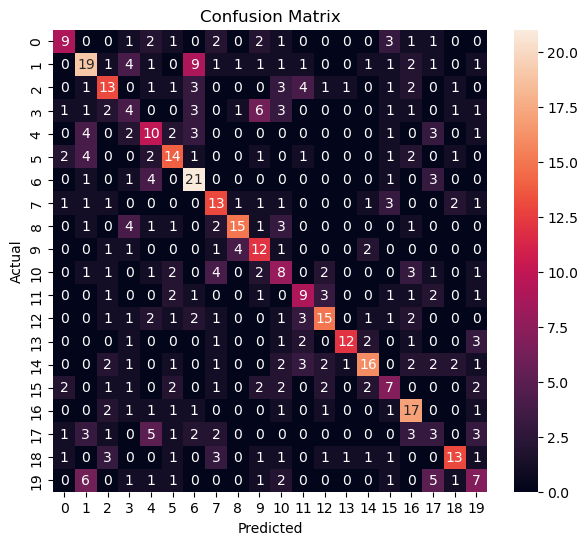

In [10]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **10. Precision & Recall**

In [11]:
print(classification_report(y_true, y_pred_classes, target_names=categories))

              precision    recall  f1-score   support

    airplane       0.53      0.39      0.45        23
   ambulance       0.45      0.42      0.44        45
     bicycle       0.43      0.41      0.42        32
        boat       0.17      0.16      0.17        25
         bus       0.32      0.38      0.35        26
         car       0.45      0.48      0.47        29
  fire_truck       0.46      0.68      0.55        31
  helicopter       0.41      0.50      0.45        26
  hovercraft       0.68      0.52      0.59        29
     jet_ski       0.39      0.55      0.45        22
       kayak       0.26      0.31      0.28        26
  motorcycle       0.39      0.41      0.40        22
    rickshaw       0.56      0.48      0.52        31
     scooter       0.80      0.52      0.63        23
      segway       0.62      0.44      0.52        36
  skateboard       0.29      0.29      0.29        24
     tractor       0.45      0.63      0.52        27
       truck       0.14    

# **11. Display Predictions**

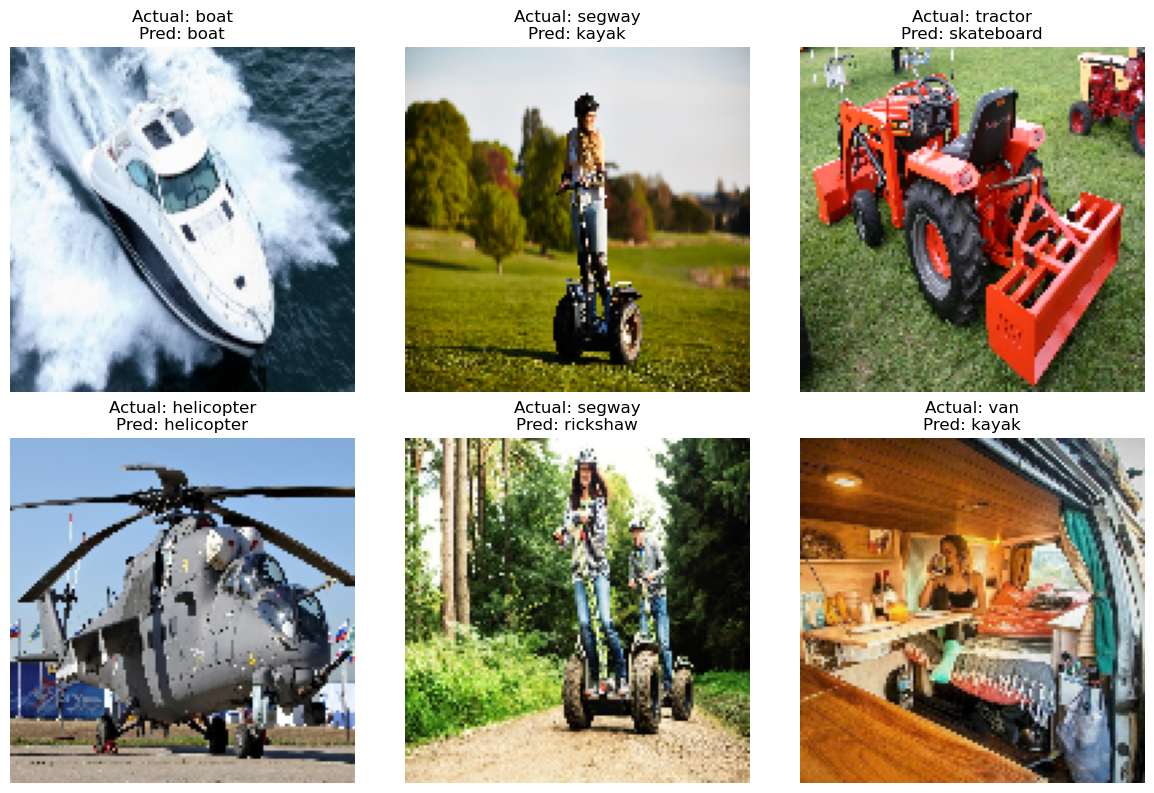

In [12]:
plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_test[i])
    plt.title(f"Actual: {categories[y_true[i]]}\nPred: {categories[y_pred_classes[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# **A. Why OpenCV was used?**
OpenCV was used for image preprocessing tasks such as reading images (cv2.imread), resizing them to a fixed size, converting color format (BGR to RGB), and normalizing pixel values. It is efficient and optimized for handling large image datasets.

# **B. CNN Architecture Chosen**
A Sequential CNN model was used with:

- 3 Convolution layers (32, 64, 128 filters)
- MaxPooling layers for downsampling
- Flatten layer
- Fully connected Dense layer (256 neurons)
- Dropout layer to reduce overfitting
- Softmax output layer for multi-class classification

# **C. Preprocessing Steps**
- Image reading using OpenCV
- Resizing to 128×128
- BGR to RGB conversion
- Pixel normalization (0–1)

# **D. Challenges Faced**
- Variation in vehicle images (angles, lighting)
- Similar classes (car vs truck)
- Large dataset increases training time
- Risk of overfitting handled using dropout